In [ ]:
import anndata as ad
import squidpy as sq
import cellcharter as cc
import pandas as pd
import scanpy as sc
import scvi
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import sc_toolbox as sct

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
mpl.rcParams["figure.figsize"] = (5, 5)

In [ ]:
plt.rcParams['pdf.fonttype'] = 42

In [ ]:
adata = sc.read('../data/cellcharter_dmg_FINAL.h5ad')
adata

AnnData object with n_obs × n_vars = 26552 × 990
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.Histone', 'Max.Histone', 'Mean.G', 'Max.G', 'Mean.rRNA_MembraneStain_B2M', 'Max.rRNA_MembraneStain_B2M', 'Mean.GFAP', 'Max.GFAP', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'sample', 'sample2', 'orig.ident', 'nCount_Nanostring', 'nFeature_Nanostring', 'Mean.rRNA_CD298_B2M', 'Max.rRNA_CD298_B2M', 'Slide_name', 'Run_name', 'ISH.concentration', 'Beta', 'tissue', 'Run_Slide_name', 'slide_ID_numeric', 'Run_Tissue_name', 'log10totalcounts', 'IFcolor', 'nb_clus', 'leiden_clus', 'id', 'FOV', 'PMCID', 'Replicate', 'ID_R', 'n_counts', '_scvi_batch', '_scvi_labels', 'cluster_cellcharter', 'tangram_prediction', 'leiden', 'cellcharter_6', 'cellcharter_9', 'cellcharter_12'
    var: 'n_counts'
    uns: 'PMCID_colors', '_cellcharter', '_scvi_manager_uuid', '_scvi_uuid', 'cluster_cellcharter_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'spatial

In [ ]:
adata.layers['scaled'] = adata.X.copy()

sc.pp.scale(adata, layer='scaled')

In [ ]:
sc.tl.rank_genes_groups(adata, "tangram_prediction", layer="counts", method="wilcoxon")
de_df = pd.DataFrame(adata.uns['rank_genes_groups']['names'])
de_df.head(20)

,RG_like,Tri_IPC_like,nIPC_like,OPC_like,COP_like,AC_like,Cilia_like,TD_like,GW_like,Oligodendrocyte,Mono_neutrophil,TAM_C1Q,TAM_lipid_laden,TAM_scavenger,TAM_IL1B,TAM_homeostatic,T_cell,B_cell,Endothelial,Mural
0,FABP7,EGFR,STMN2,MMP16,GPR17,AQP4,CLU,CHI3L1,HSPB1,SELENOP,LYZ,CD74,GPNMB,CD163,CD74,CX3CR1,IL7R,JCHAIN,IGFBP7,COL1A1
1,CLU,HES6,RBFOX3,OLIG1,SOX10,AQP1,AQP4,ITGA3,VIM,PTGDS,CD74,C1QC,SPP1,MRC1,CCL3,P2RY12,CD2,MS4A1,FLT1,COL3A1
2,VIM,DLL1,MET,PDGFRA,BCAS1,SPARCL1,SPARCL1,VEGFA,TGFB2,AATK,CLEC12A,SPP1,RGS1,CD74,OLR1,CD74,ITK,IRF4,ITM2A,COL1A2
3,MT1X,DLL3,BMP5,SOX10,BCAN,CLU,NTRK2,MEG3,JUN,APOD,HLA-DRA,GPX1,CD163,HLA-DRB1,CSF1R,ITGAX,IL32,MZB1,VWF,FN1
4,CD63,OLIG1,NRXN1,MYC,MMP16,NTRK2,GFAP,TIMP1,MEG3,GSN,HLA-DPA1,C1QB,TNFRSF14,HLA-DRA,SPP1,CSF1R,GZMA,HBA1,EPAS1,DCN
5,SOX2,METTL7B,NRG1,RPL34,FYN,CD38,AQP1,VIM,S100A6,FGFR2,CD163,HLA-DRA,ITGAX,C1QC,ITGAX,CSF2RA,STAT4,BMP6,ESAM,IGFBP7
6,CALM2,RARRES2,CHGA,BCAN,MYC,BCAN,SOX9,LGALS3,COL6A2,NDRG1,RGS2,B2M,C1QC,HLA-DPA1,IL1B,LPAR5,RUNX3,P2RX5,ENG,COL4A2
7,HSPB1,HES5,KRT24,CD24,RPL34,FGFR3,MALAT1,CAV1,MZT2A,FGF1,HLA-DRB1,HLA-DPA1,SRGN,SRGN,HLA-DRA,MAF,CCL5,SELL,CD34,COL4A1
8,SOX9,MEG3,MYH11,SOX4,SOX4,GFAP,DDR1,HILPDA,HGF,COL4A5,SRGN,SRGN,FCGR3A,HLA-DRB5,CSF2RA,SPP1,TXK,ESR1,FN1,PDGFRB
9,MT2A,CCND1,WNT7A,FGF12,RPL21,AGT,CRYAB,DUSP4,S100A10,COL18A1,CLEC7A,FCGR3A,CD68,C1QB,CX3CR1,C1QC,HBA1,ADGRG5,IFITM3,BGN


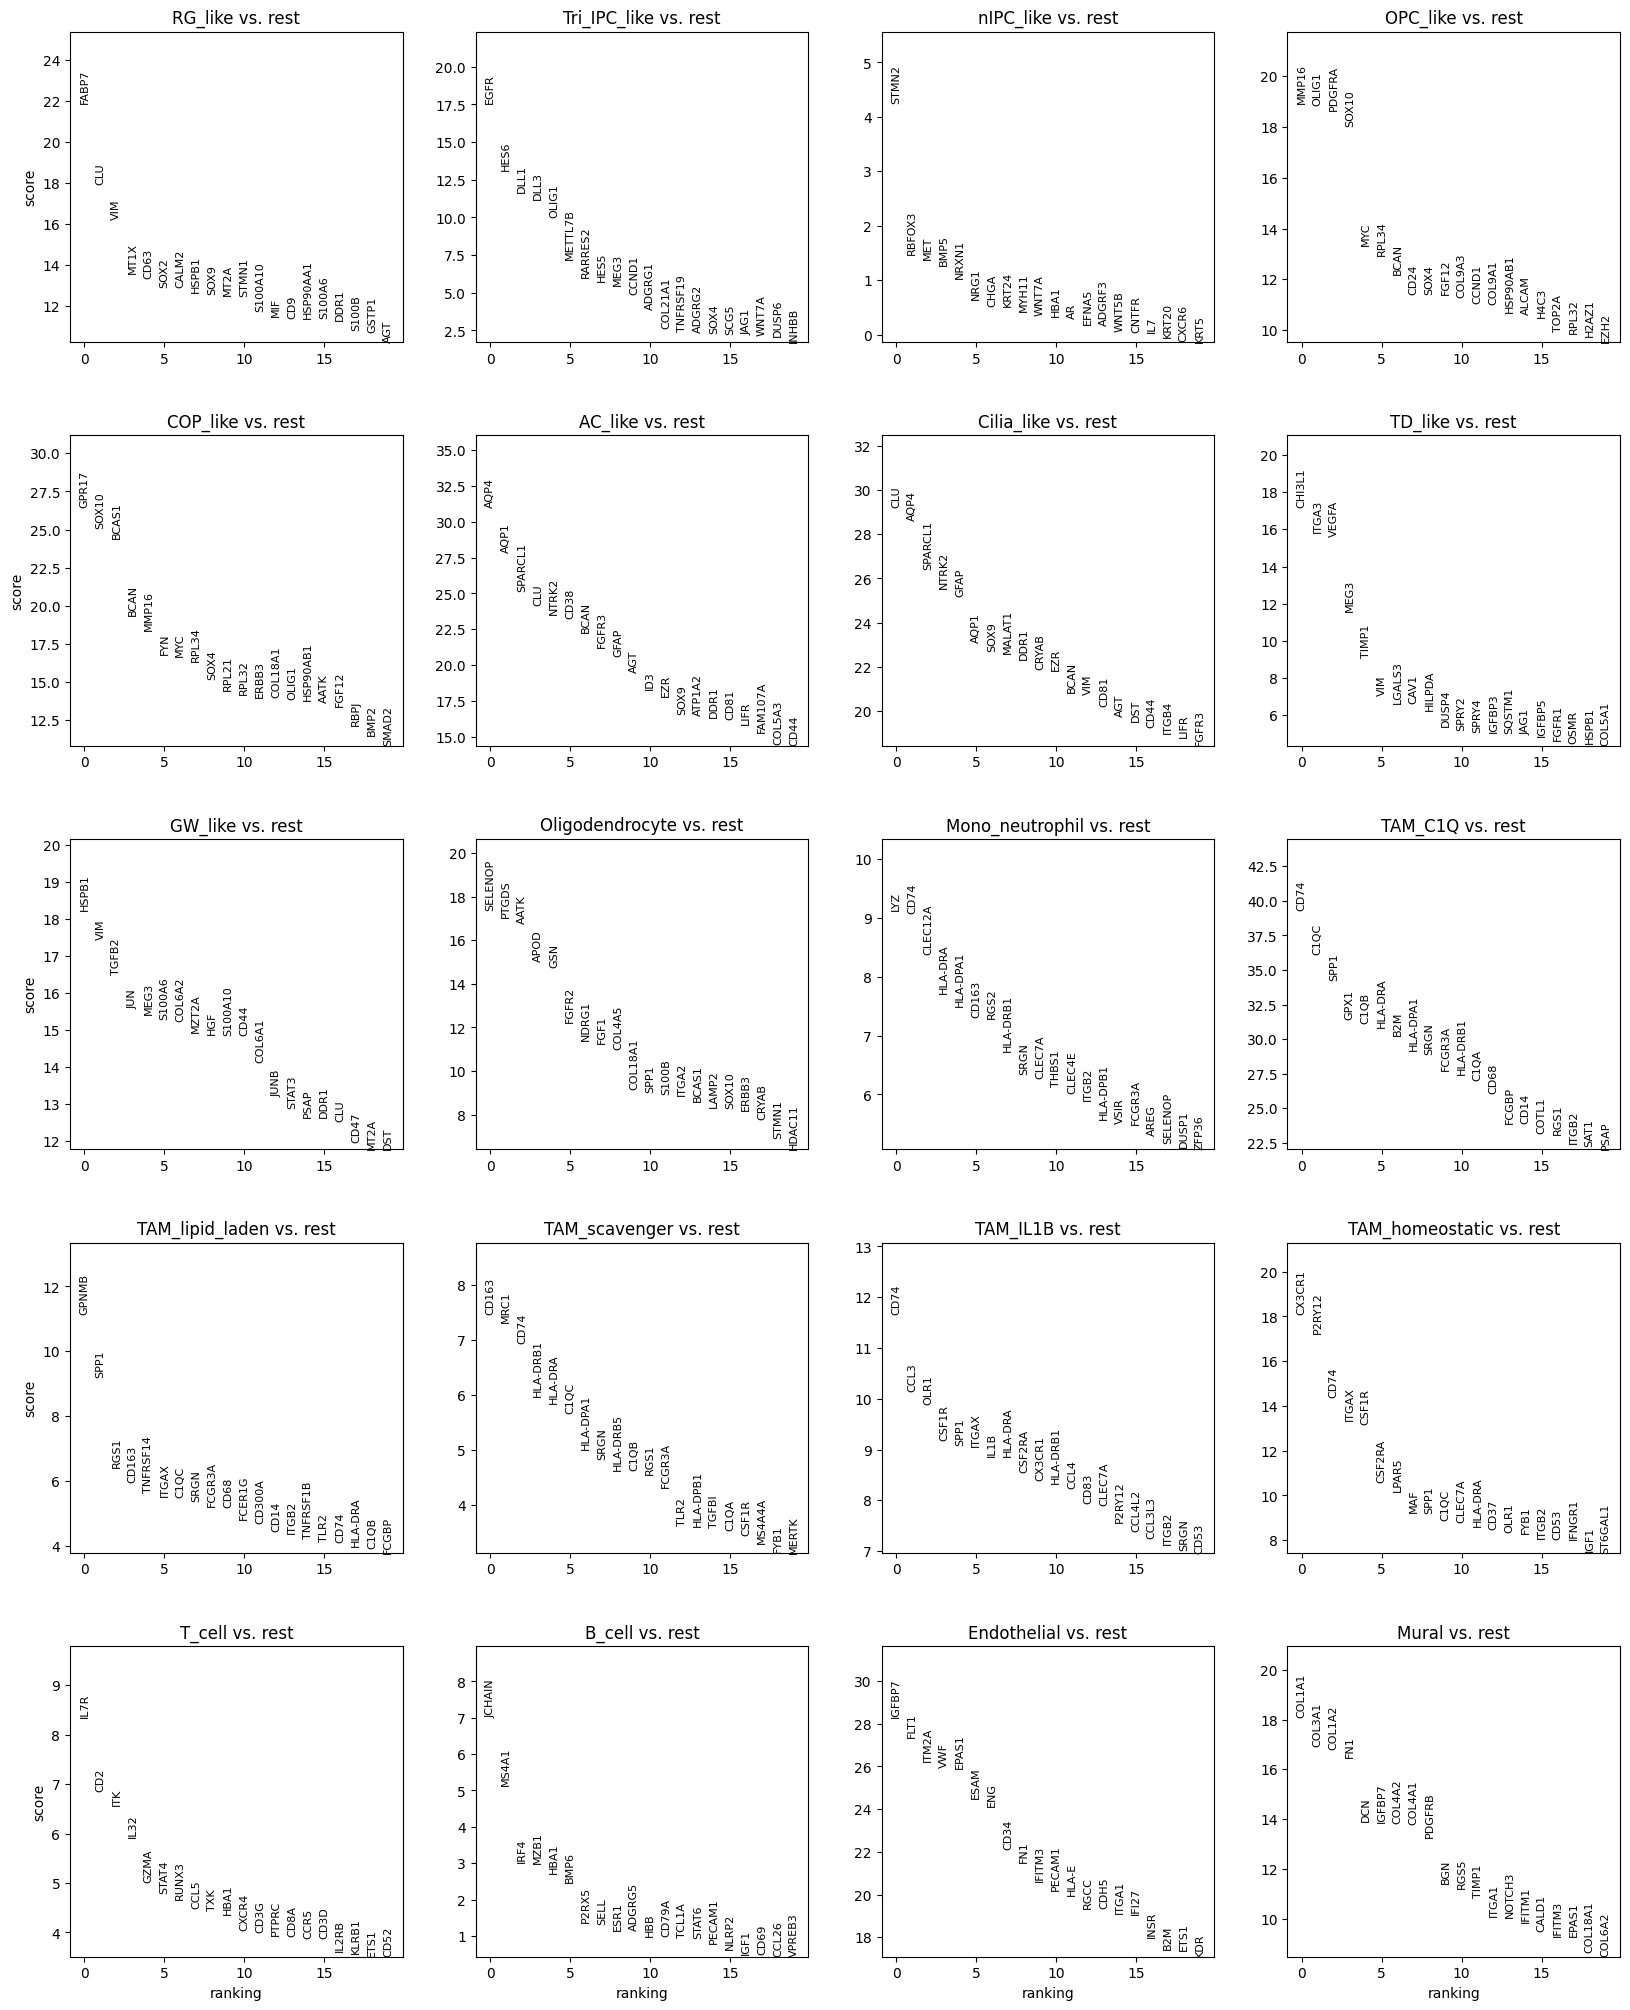

In [ ]:
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

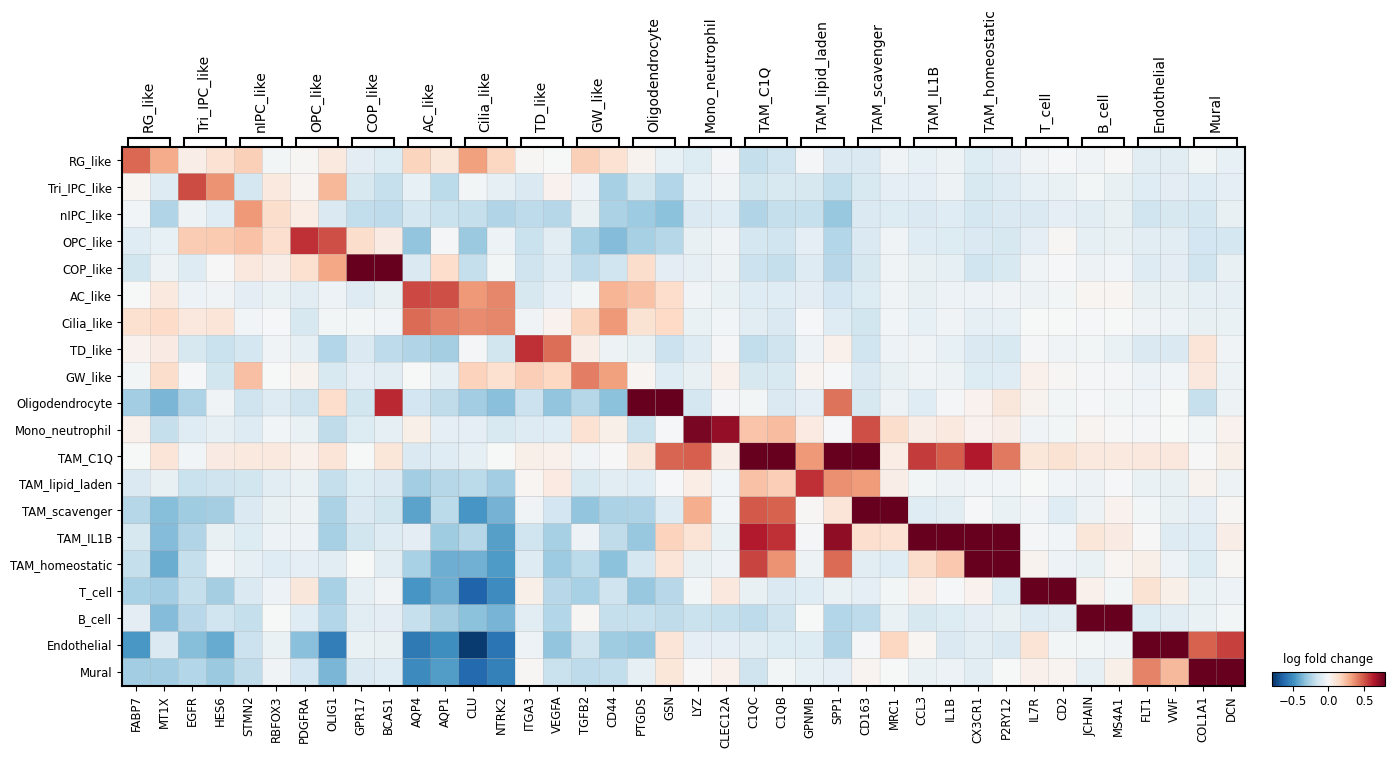

In [ ]:
order = [
    'RG_like', 'Tri_IPC_like', 'nIPC_like', 'OPC_like',
    'COP_like', 'AC_like', 'Cilia_like', 'TD_like', 'GW_like',
    'Oligodendrocyte', 'Mono_neutrophil', 'TAM_C1Q',
    'TAM_lipid_laden', 'TAM_scavenger', 'TAM_IL1B',
    'TAM_homeostatic', 'T_cell', 'B_cell', 'Endothelial', 'Mural'
]

values = [
    ["FABP7", "MT1X"],
    ["EGFR", "HES6"],
    ["STMN2", "RBFOX3"],
    ["PDGFRA", "OLIG1"],
    ["GPR17", "BCAS1"],
    ["AQP4", "AQP1"],
    ["CLU", "NTRK2"],
    ["ITGA3", "VEGFA"],
    ["TGFB2", "CD44"],
    ["PTGDS", "GSN"],
    ["LYZ", "CLEC12A"],
    ["C1QC", "C1QB"],
    ["GPNMB", "SPP1"],
    ["CD163", "MRC1"],
    ["CCL3", "IL1B"],
    ["CX3CR1", "P2RY12"],
    ["IL7R", "CD2"],
    ["JCHAIN", "MS4A1"],
    ["FLT1", "VWF"],
    ["COL1A1", "DCN"]
]

marker_genes = dict(zip(order, values))

dp = sc.pl.matrixplot(
    adata,
    marker_genes,
    groupby='tangram_prediction',
    cmap='RdBu_r', 
    vmin=-0.8,
    vmax=0.8,
    colorbar_title='log fold change',
    layer="scaled",
    save='figures/marker_genes_tangram_cosmx.pdf'
)
